<a href="https://colab.research.google.com/github/Sandip-Kr-Yadav/MLDatasetPractice/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [239]:
# %pip install seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [240]:
#Reading Dataset
df_data=pd.read_csv('Titanic_test.csv')
df_survived=pd.read_csv('gender_submission.csv')
df=pd.merge(df_data, df_survived, on='PassengerId')
df_original=df.copy()

In [241]:
#Data Inspection
display(df_original.head())
print('\n')
print(df_original.info())
print('\n')
print(df_original.describe())
print('\n')
print(df_original.shape)
print('\n')
display(df_original.columns)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  Survived     418 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None


       PassengerId      Pclass         Age       SibSp       Parch  \
count   418.000000  418.000000  332.000000  418.000000  418.000000   
mean   1100.500000    2.265550   30.272590    0.447368    0.392344   
std     120.810458    0.8

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Survived'],
      dtype='object')

In [242]:
# Handling missing values
print(df.isnull().sum())

numeric_col_names = df.select_dtypes(include=np.number).columns.tolist()
for col in numeric_col_names:
    df[col]=df[col].fillna(df[col].mean()) # Numercal
df.fillna("Unknown", inplace=True)   # categorical

display(df.isnull().sum())

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Survived         0
dtype: int64


,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


In [243]:
# Handling duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)
display(df)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.50000,0,0,330911,7.8292,Unknown,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00000,1,0,363272,7.0000,Unknown,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.00000,0,0,240276,9.6875,Unknown,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.00000,0,0,315154,8.6625,Unknown,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00000,1,1,3101298,12.2875,Unknown,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,30.27259,0,0,A.5. 3236,8.0500,Unknown,S,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.00000,0,0,PC 17758,108.9000,C105,C,1
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.50000,0,0,SOTON/O.Q. 3101262,7.2500,Unknown,S,0
416,1308,3,"Ware, Mr. Frederick",male,30.27259,0,0,359309,8.0500,Unknown,S,0


In [244]:
#Drop cabin column as too many missing values
df.drop('Cabin', axis=1, inplace=True)
display(df)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.50000,0,0,330911,7.8292,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00000,1,0,363272,7.0000,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.00000,0,0,240276,9.6875,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.00000,0,0,315154,8.6625,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00000,1,1,3101298,12.2875,S,1
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,30.27259,0,0,A.5. 3236,8.0500,S,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.00000,0,0,PC 17758,108.9000,C,1
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.50000,0,0,SOTON/O.Q. 3101262,7.2500,S,0
416,1308,3,"Ware, Mr. Frederick",male,30.27259,0,0,359309,8.0500,S,0


In [245]:
df_numeric = df.select_dtypes(include=['number'])
df_numeric.drop(['PassengerId','Survived'], axis=1, inplace=True)
display(df_numeric)

,Pclass,Age,SibSp,Parch,Fare
0,3,34.50000,0,0,7.8292
1,3,47.00000,1,0,7.0000
2,2,62.00000,0,0,9.6875
3,3,27.00000,0,0,8.6625
4,3,22.00000,1,1,12.2875
...,...,...,...,...,...
413,3,30.27259,0,0,8.0500
414,1,39.00000,0,0,108.9000
415,3,38.50000,0,0,7.2500
416,3,30.27259,0,0,8.0500


In [246]:
#Remove outliers
for col in df_numeric:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df[col] = np.where(df[col] > upper_bound, upper_bound,
                     np.where(df[col] < lower_bound, lower_bound, df[col]))

In [247]:
# plt.figure(figsize=(20, 10))
# plt.subplot(1, 2, 1)
# for col in df_numeric:

#   sns.boxplot(df_original[col])
# # sns.boxplot(y=df_original['Fare'])
# plt.title('Before Capping')

# plt.subplot(1, 2, 2)
# for col in df_numeric:
#   sns.boxplot(df[col])
# sns.boxplot(y=df['Fare'])
# plt.title('After Capping')
# plt.show()

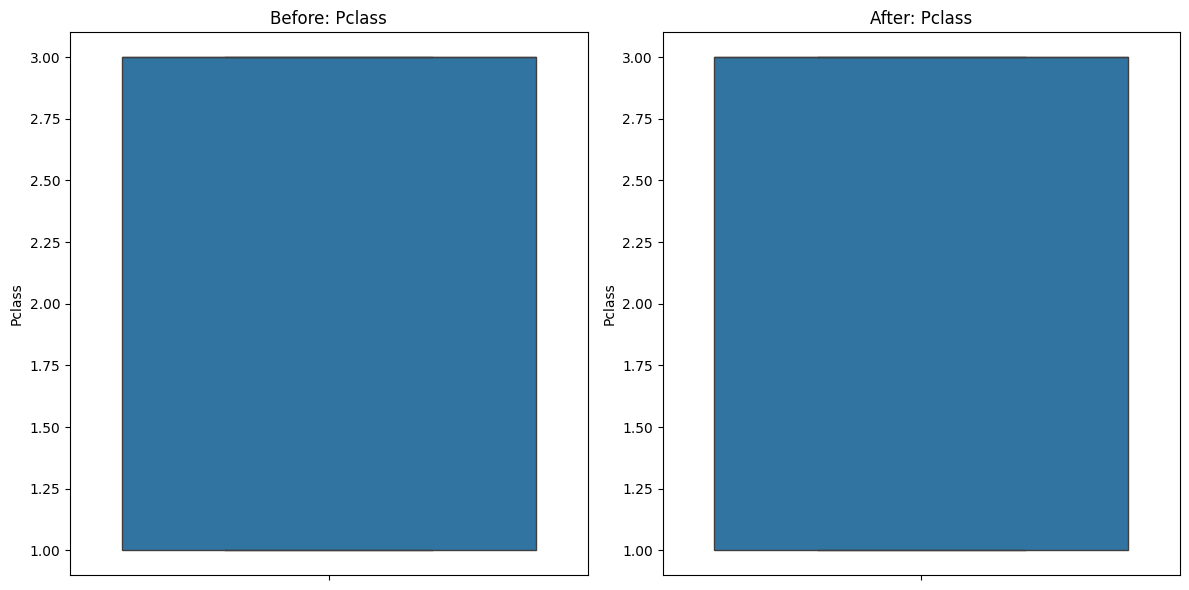

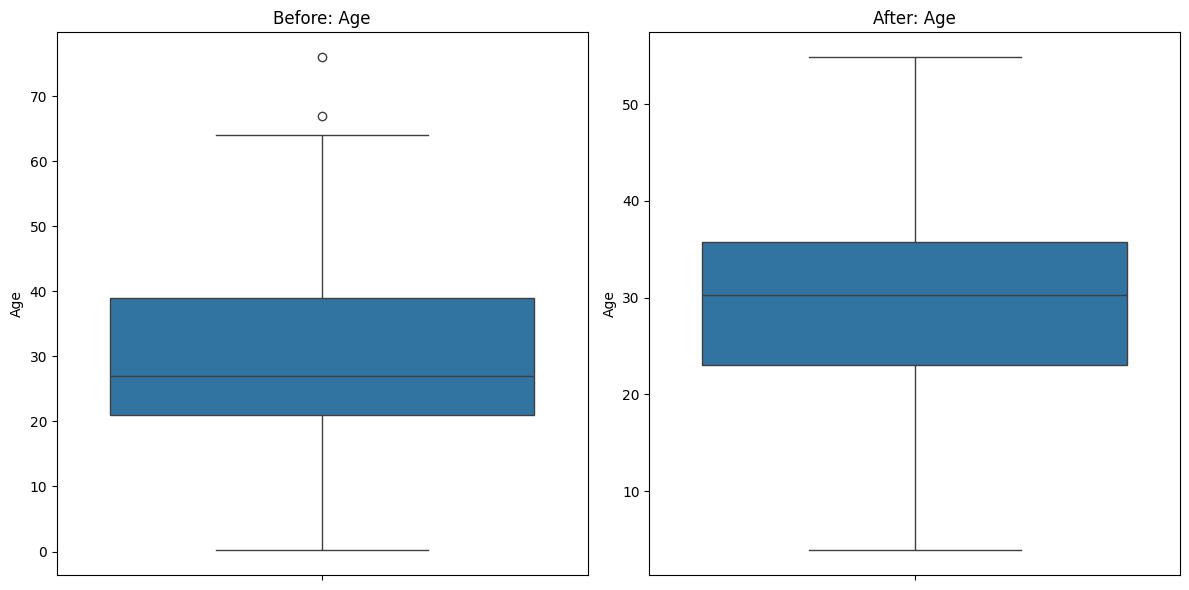

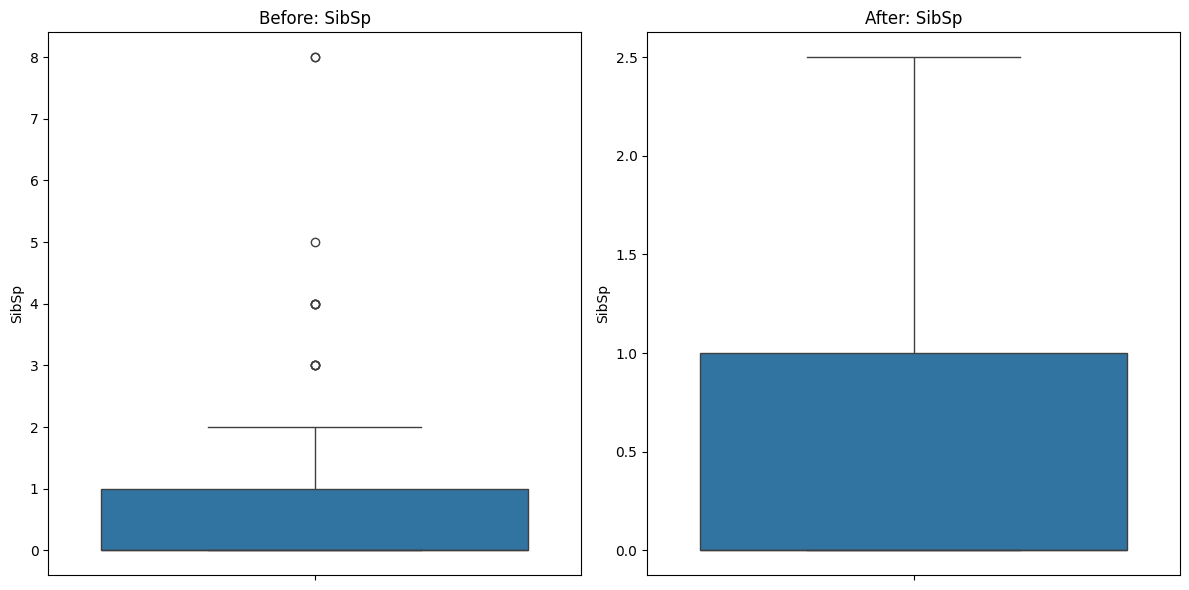

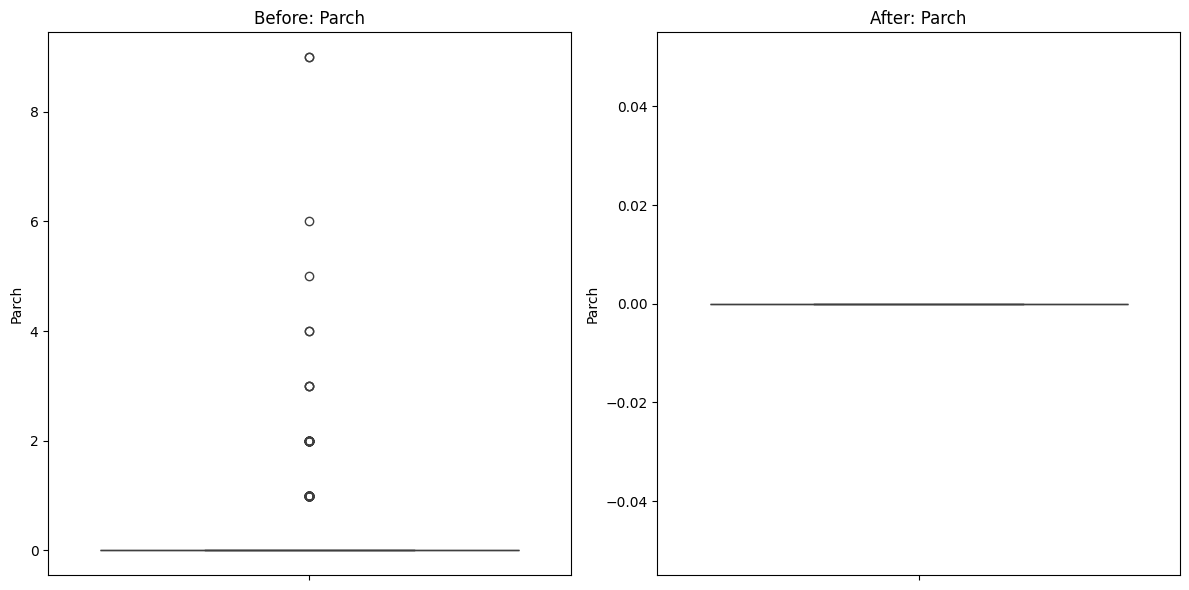

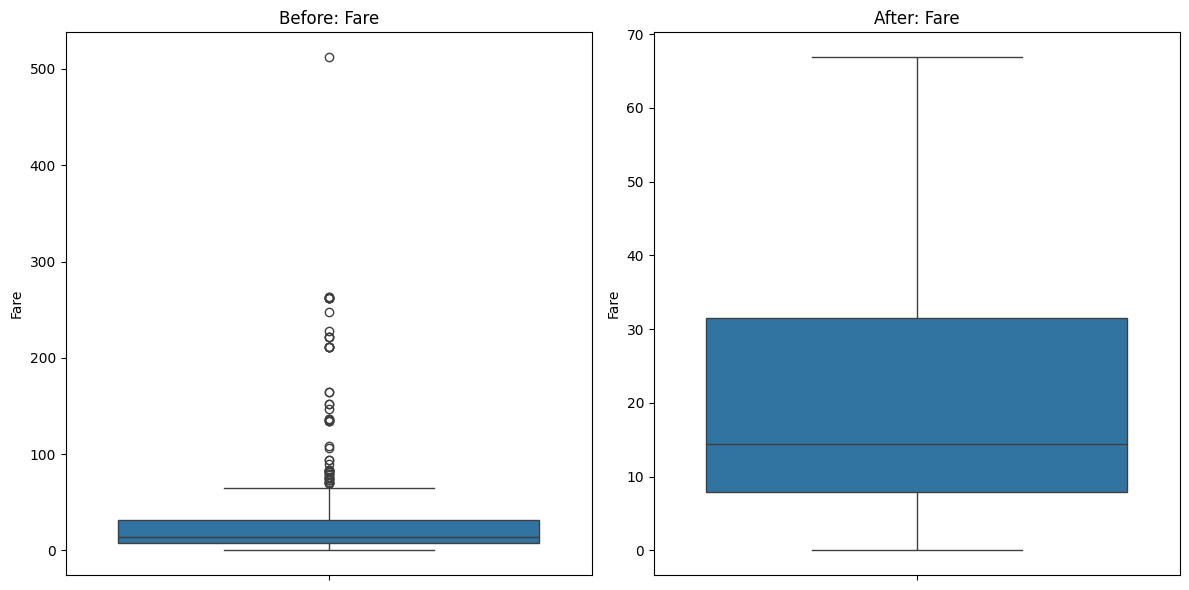

In [248]:
# Set the figure size
for col in df_numeric:
    plt.figure(figsize=(12, 6))

    # Subplot 1: Before Capping
    plt.subplot(1, 2, 1)
    sns.boxplot(y=df_original[col])
    plt.title(f'Before: {col}')

    # Subplot 2: After Capping
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f'After: {col}')

    plt.tight_layout()
    plt.show()

In [250]:
#Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
display(df)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived,FamilySize
0,892,3.0,"Kelly, Mr. James",0,34.50000,0.0,0.0,330911,7.8292,Q,0,1.0
1,893,3.0,"Wilkes, Mrs. James (Ellen Needs)",1,47.00000,1.0,0.0,363272,7.0000,S,1,2.0
2,894,2.0,"Myles, Mr. Thomas Francis",0,54.87500,0.0,0.0,240276,9.6875,Q,0,1.0
3,895,3.0,"Wirz, Mr. Albert",0,27.00000,0.0,0.0,315154,8.6625,S,0,1.0
4,896,3.0,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.00000,1.0,0.0,3101298,12.2875,S,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3.0,"Spector, Mr. Woolf",0,30.27259,0.0,0.0,A.5. 3236,8.0500,S,0,1.0
414,1306,1.0,"Oliva y Ocana, Dona. Fermina",1,39.00000,0.0,0.0,PC 17758,66.9063,C,1,1.0
415,1307,3.0,"Saether, Mr. Simon Sivertsen",0,38.50000,0.0,0.0,SOTON/O.Q. 3101262,7.2500,S,0,1.0
416,1308,3.0,"Ware, Mr. Frederick",0,30.27259,0.0,0.0,359309,8.0500,S,0,1.0


In [251]:
# The Analysis (EDA)

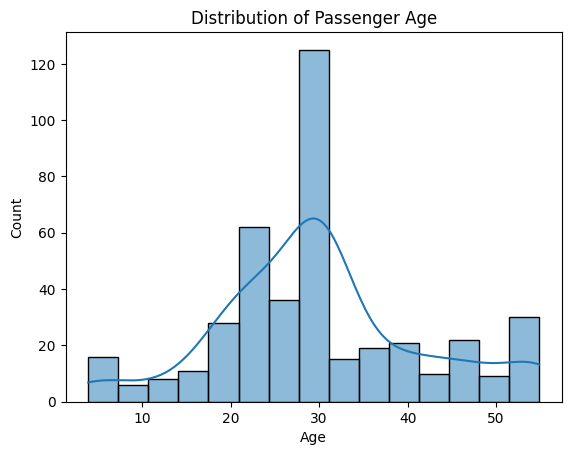

In [252]:
#Univariate Analysis
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Passenger Age')
plt.show()

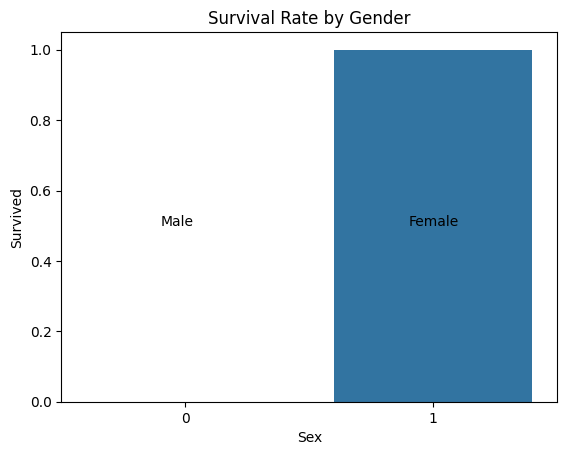

In [265]:
#Bivariate Analysis
sns.barplot(x='Sex', y='Survived', data=df)
plt.text(-0.1, 0.5, 'Male')
plt.text(0.9, 0.5, 'Female')
plt.title('Survival Rate by Gender')
plt.show()

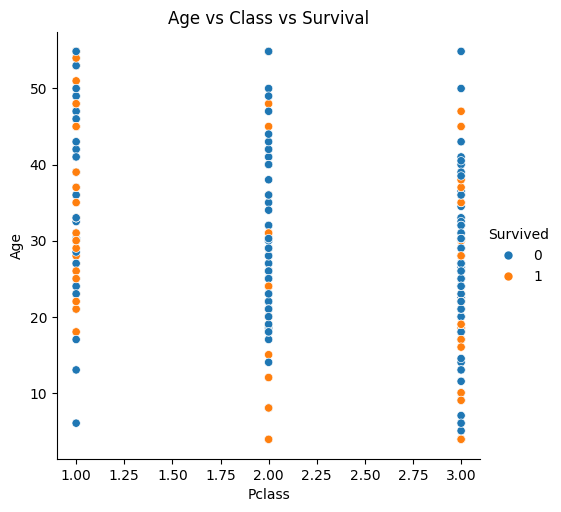

In [254]:
#Multivariate Analysis
sns.relplot(x='Pclass', y='Age', hue='Survived', data=df)
plt.title('Age vs Class vs Survival')
plt.show()


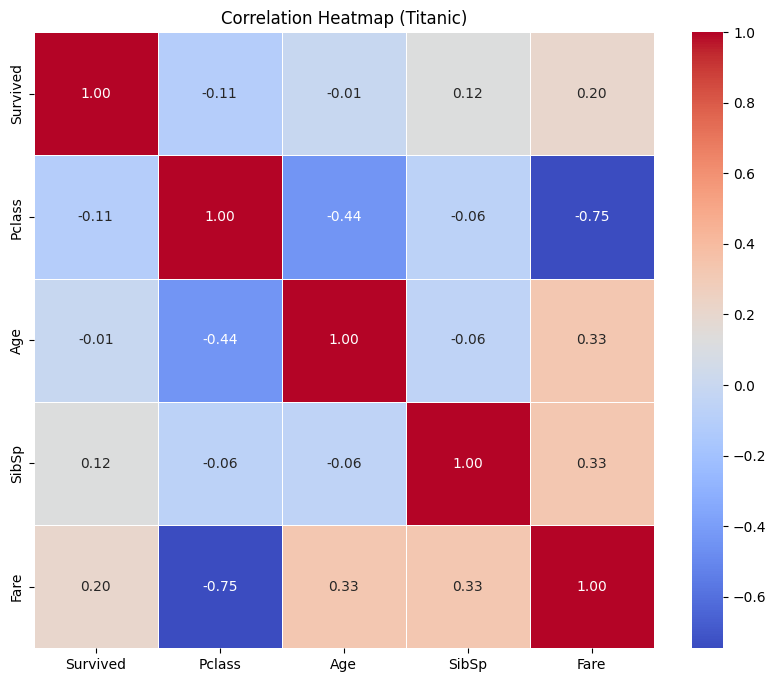

In [255]:
# Select only numerical columns for the correlation matrix
features_for_heatmap = ['Survived', 'Pclass', 'Age', 'SibSp', 'Fare']

# Create the dataframe
numerical_df = df[features_for_heatmap]

# Generate the Correlation Matrix
corr_matrix = numerical_df.corr()

# Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Titanic)')
plt.show()